In [3]:
import pandas as pd
# numpy — for numerical operations and handling infinity/NaN values
import numpy as np
# matplotlib — for plotting charts and graphs
import matplotlib.pyplot as plt
# warnings — hide unnecessary output so our notebook stays clean
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/IPL.csv.xls')
# .shape tells us (number of rows, number of columns)
print('Shape:', df.shape)
df.head()

Shape: (278205, 64)


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
match_id,0
date,0
match_type,0
event_name,0
...,...
batter_balls,0
bowler_wicket,0
batting_partners,0
next_batter,264884


In [6]:
df = df[df['innings'] == 2].copy()
# dropna(subset=[...]) removes rows where the specified column is missing
# runs_target is NaN in 1st innings rows — we've already removed those,
# but this is a safety check
df = df.dropna(subset=['runs_target'])
# Remove rows where city is 'Unknown' — we can't use unknown cities
# as a feature for the model
df = df[df['city'] != 'Unknown']
# Print how many rows remain after cleaning
print('Rows remaining:', len(df))

Rows remaining: 127891


In [7]:
team_rename = {
'Delhi Daredevils' : 'Delhi Capitals', # renamed in 2019
'Deccan Chargers' : 'Sunrisers Hyderabad', # replaced in 2013
'Kings XI Punjab' : 'Punjab Kings', # renamed in 2021
'Rising Pune Supergiant' : 'Rising Pune Supergiants', # name fix
'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru', # renamed in 2023
}
# Apply the rename to all three team-related columns
# .replace() swaps old values with new values based on the dictionary
for col in ['batting_team', 'bowling_team', 'match_won_by']:
    df[col] = df[col].replace(team_rename)

In [8]:
TEAMS = ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans',
'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians',
'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru',
'Sunrisers Hyderabad']
# .isin(TEAMS) returns True only if the value is in our TEAMS list
# We apply this to BOTH batting and bowling team columns using & (AND)
# This removes defunct teams like Kochi Tuskers, Pune Warriors etc.
df = df[df['batting_team'].isin(TEAMS) & df['bowling_team'].isin(TEAMS)]
# Verify — should show exactly 10 teams
print('Teams:', sorted(df['batting_team'].unique()))

Teams: ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Punjab Kings', 'Rajasthan Royals', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [9]:
# We can't divide by 0 when calculating run rates
df = df[df['team_balls'] > 0]
# How many more runs does the batting team need to win?
df['runs_left'] = df['runs_target'] - df['team_runs']
# How many valid balls are remaining? (T20 = 120 balls total)
# team_balls counts only legal deliveries (not wides/no-balls)
df['balls_left'] = 120 - df['team_balls']
# How many wickets does the batting team still have?
df['wickets_remaining'] = 10 - df['team_wicket']
# Current Run Rate = runs scored so far per over
# (team_balls / 6) converts balls to overs
df['crr'] = (df['team_runs'] * 6 / df['team_balls']).round(2)
# Required Run Rate = runs still needed per over remaining
df['rrr'] = (df['runs_left'] * 6 / df['balls_left']).round(2)
# Target variable: 1 if the batting team won, 0 if they lost
# This is what the model will learn to predict
df['result'] = (df['batting_team'] == df['match_won_by']).astype(int)

In [10]:
FEATURES = ['batting_team', 'bowling_team', 'city',
'runs_left', 'balls_left', 'wickets_remaining',
'runs_target', 'crr', 'rrr', 'result']
# Create a clean copy with only these columns
final_df = df[FEATURES].copy()
# Replace infinity values (happen when dividing by zero) with NaN
# Then drop any rows that have NaN in any column
# np.inf = positive infinity, -np.inf = negative infinity
final_df = final_df.replace([np.inf, -np.inf], np.nan).dropna()
# Confirm the final shape of our clean dataset
print('Final shape:', final_df.shape)
final_df.head()


Final shape: (114506, 10)


,batting_team,bowling_team,city,runs_left,balls_left,wickets_remaining,runs_target,crr,rrr,result
124,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,222.0,119,10,223.0,6.0,11.19,0
125,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,221.0,119,10,223.0,12.0,11.14,0
126,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,221.0,118,10,223.0,6.0,11.24,0
127,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,220.0,117,10,223.0,6.0,11.28,0
128,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,219.0,116,10,223.0,6.0,11.33,0


In [11]:
win_pct = (final_df.groupby('batting_team')['result']
.mean().sort_values(ascending=False) * 100).round(1)
print(win_pct)

batting_team
Gujarat Titans                 65.4
Chennai Super Kings            61.4
Kolkata Knight Riders          56.6
Mumbai Indians                 54.1
Rajasthan Royals               53.5
Royal Challengers Bengaluru    49.9
Punjab Kings                   45.8
Delhi Capitals                 45.2
Sunrisers Hyderabad            41.1
Lucknow Super Giants           40.0
Name: result, dtype: float64


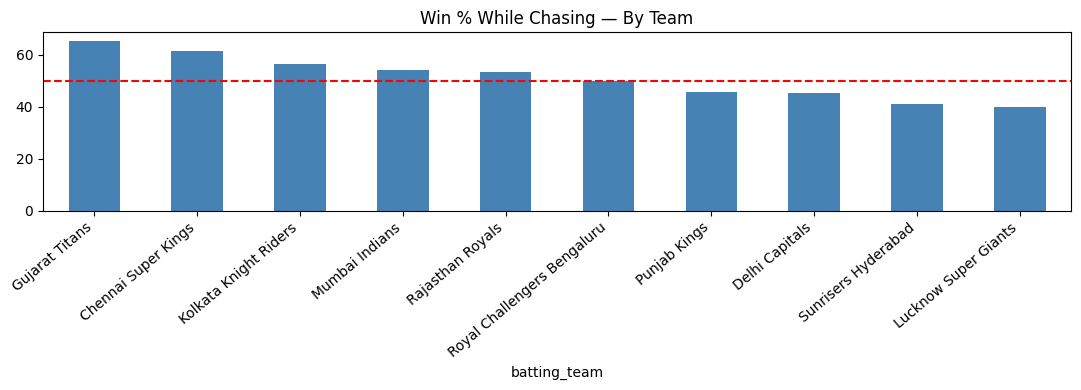

In [12]:
win_pct.plot(kind='bar', figsize=(11, 4), color='steelblue')
# Add a title to the chart
plt.title('Win % While Chasing — By Team')
# Draw a horizontal red dashed line at 50% for reference
plt.axhline(50, color='red', linestyle='--', label='50%')
# Rotate x-axis labels so team names don't overlap
plt.xticks(rotation=40, ha='right')
# Automatically adjust spacing so nothing gets cut off
plt.tight_layout()
# Display the chart
plt.show()

In [13]:
final_df.to_csv('IPL_processed_dataset.csv', index=False)
print('Saved processed_dataset.csv')
print('Rows:', len(final_df))
print()

Saved processed_dataset.csv
Rows: 114506



In [14]:
import pickle
# train_test_split — splits our data into training set and testing set
from sklearn.model_selection import train_test_split
# ColumnTransformer — applies different steps to different types of columns
from sklearn.compose import ColumnTransformer
# OneHotEncoder — converts team names/city (text) into numbers the model understands
# StandardScaler — rescales numbers so large values don't dominate small ones
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Pipeline — chains preprocessing and the model into one object
from sklearn.pipeline import Pipeline
# LogisticRegression — our model. Despite the name, it predicts probability (0 to 1)
from sklearn.linear_model import LogisticRegression
# accuracy_score — tells us what % of predictions the model got right
from sklearn.metrics import accuracy_score


In [15]:
df = pd.read_csv('/content/IPL_processed_dataset.csv')
# Check how many rows and columns we have
print('Shape:', df.shape)
# Preview the first few rows
df.head()

Shape: (114506, 10)


,batting_team,bowling_team,city,runs_left,balls_left,wickets_remaining,runs_target,crr,rrr,result
0,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,222.0,119,10,223.0,6.0,11.19,0
1,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,221.0,119,10,223.0,12.0,11.14,0
2,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,221.0,118,10,223.0,6.0,11.24,0
3,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,220.0,117,10,223.0,6.0,11.28,0
4,Royal Challengers Bengaluru,Kolkata Knight Riders,Bangalore,219.0,116,10,223.0,6.0,11.33,0


In [16]:
X = df.drop('result', axis=1) # axis=1 means drop a column (not a row)
# y = the target column — what we want the model to predict
# 1 = batting team wins, 0 = batting team loses
y = df['result']
# Split into train and test sets
# test_size=0.25 means 25% goes to testing, 75% to training
# random_state=42 makes the split the same every time you run it
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=42)
print('Training rows:', len(X_train))
print('Testing rows: ', len(X_test))

Training rows: 85879
Testing rows:  28627


In [17]:
CATEGORICAL = ['batting_team', 'bowling_team', 'city']
NUMERIC = ['runs_left', 'balls_left', 'wickets_remaining',
'runs_target', 'crr', 'rrr']
# ColumnTransformer applies different transformations to different columns
# 'cat' — apply OneHotEncoder to categorical columns
# 'num' — apply StandardScaler to numeric columns
preprocessor = ColumnTransformer([
('cat', OneHotEncoder(
sparse_output=False, # return a regular array, not a sparse matrix
drop='first', # drop first category to avoid redundancy
handle_unknown='ignore' # ignore unseen categories at prediction time
), CATEGORICAL),
('num', StandardScaler(), NUMERIC) # rescale numeric columns
])
# Pipeline chains step1 (preprocessing) and step2 (model) together
# When we call pipe.fit() or pipe.predict(), both steps run in order
pipe = Pipeline([
('step1', preprocessor), # preprocess first
('step2', LogisticRegression(solver='liblinear', max_iter=1000)) # then train model
])
print('Pipeline built!')

Pipeline built!


In [18]:
pipe.fit(X_train, y_train)
print('Model trained!')


Model trained!


In [19]:
y_pred = pipe.predict(X_test)
# accuracy_score compares our predictions (y_pred) to the correct answers (y_test)
# Returns a number between 0 and 1 — multiply by 100 for percentage
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc * 100:.2f}%')


Accuracy: 80.24%


In [21]:
pickle.dump(pipe, open('pipe.pkl', 'wb'))
print('Saved: pipe.pkl')
# Load it back to verify it works correctly
# open('pipe.pkl', 'rb') opens the file in read-binary mode
loaded = pickle.load(open('pipe.pkl', 'rb'))
# Check the accuracy is the same as before saving
verify_acc = accuracy_score(y_test, loaded.predict(X_test))
print(f'Reload accuracy: {verify_acc * 100:.2f}% ✓')

# Note: This 'pipe.pkl' file stores the trained model. Deleting it will prevent future predictions without retraining.

Saved: pipe.pkl
Reload accuracy: 80.24% ✓


In [22]:
import ipywidgets as widgets
from IPython.display import display

# Get unique cities from the processed dataframe
ALL_CITIES = sorted(df['city'].unique().tolist())

### Enter Match Details for Prediction

In [25]:
# Create widgets for each input feature

# Dropdowns for categorical features
batting_team_widget = widgets.Dropdown(
    options=TEAMS,
    description='Batting Team:',
    disabled=False,
    continuous_update=False
)
bowling_team_widget = widgets.Dropdown(
    options=TEAMS,
    description='Bowling Team:',
    disabled=False,
    continuous_update=False
)
city_widget = widgets.Dropdown(
    options=ALL_CITIES,
    description='City:',
    disabled=False,
    continuous_update=False
)

# Text inputs for numerical features
runs_left_widget = widgets.IntText(
    value=50,
    description='Runs Left:',
    disabled=False
)
balls_left_widget = widgets.IntText(
    value=30,
    description='Balls Left:',
    disabled=False
)
wickets_remaining_widget = widgets.IntText(
    value=7,
    description='Wickets Remaining:',
    disabled=False
)
runs_target_widget = widgets.IntText(
    value=180,
    description='Target Score:',
    disabled=False
)
crr_widget = widgets.FloatText(
    value=9.0,
    description='Current RR:',
    disabled=False
)
rrr_widget = widgets.FloatText(
    value=10.0,
    description='Required RR:',
    disabled=False
)

# Prediction button
predict_button = widgets.Button(description='Predict Win Probability')
output_widget = widgets.Output()

# Display widgets
display(
    batting_team_widget, bowling_team_widget, city_widget,
    runs_left_widget, balls_left_widget, wickets_remaining_widget,
    runs_target_widget, crr_widget, rrr_widget,
    predict_button, output_widget
)

Dropdown(description='Batting Team:', options=('Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kol…

Dropdown(description='Bowling Team:', options=('Chennai Super Kings', 'Delhi Capitals', 'Gujarat Titans', 'Kol…

Dropdown(description='City:', options=('Abu Dhabi', 'Ahmedabad', 'Bangalore', 'Bengaluru', 'Bloemfontein', 'Ca…

IntText(value=50, description='Runs Left:')

IntText(value=30, description='Balls Left:')

...

IntText(value=180, description='Target Score:')

FloatText(value=9.0, description='Current RR:')

FloatText(value=10.0, description='Required RR:')

Button(description='Predict Win Probability', style=ButtonStyle())

Output()

In [24]:
def on_predict_button_clicked(b):
    with output_widget:
        output_widget.clear_output()
        try:
            # Create a DataFrame from the widget values
            input_data = pd.DataFrame({
                'batting_team': [batting_team_widget.value],
                'bowling_team': [bowling_team_widget.value],
                'city': [city_widget.value],
                'runs_left': [runs_left_widget.value],
                'balls_left': [balls_left_widget.value],
                'wickets_remaining': [wickets_remaining_widget.value],
                'runs_target': [runs_target_widget.value],
                'crr': [crr_widget.value],
                'rrr': [rrr_widget.value]
            })

            # Predict probabilities using the loaded model
            prediction = pipe.predict_proba(input_data)

            win_prob_batting_team = round(prediction[0][1] * 100, 2)
            win_prob_bowling_team = round(prediction[0][0] * 100, 2)

            print(f'{batting_team_widget.value} Win Probability: {win_prob_batting_team}%')
            print(f'{bowling_team_widget.value} Win Probability: {win_prob_bowling_team}%')
        except Exception as e:
            print(f"An error occurred: {e}")

# Attach the function to the button click event
predict_button.on_click(on_predict_button_clicked)